# Thin conviction, measured
## PBMRS regime calibration for WTI, 2 January?31 July 2026

FRED WTI is the primary inference series and FRED Brent is the primary replication series. With all 144 WTI returns, the selected eight-lag adequacy test rejects the stable grid through J=0.80; masking 8 April in its existing grid position reverses that decision at every tested J. The higher non-rejected points in the full sample are empirically pathological, so none supports a clean near-critical estimate.

This notebook operationalizes?rather than uniquely translates?the GMSG deck language about thin positioning and round trips. J times beta equals one is a theoretical agent-layer reference, not a proven boundary for the coupled market system. April masking is a post-hoc influence sensitivity, and every claim is restricted to base.yaml, the exact tested J grid, and the predeclared D-sum statistic.

In [1]:
from __future__ import annotations
import dataclasses, hashlib, json, platform, subprocess
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from IPython.display import display

from pbmrs_core import SimConfig, __version__, acf_r2_profile, load_config
from pbmrs_core.calibration import (
    evaluate_profile_bank, lag_contributions, load_npz_cache, wilson_interval,
)
from pbmrs_core.commodities import (
    CFTC_DEFINITIONS, bootstrap_statistic, fetch_cftc_positioning,
    fetch_fred_series, read_manifest,
)

HERE = Path.cwd()
ROOT = HERE.parent if HERE.name == "notebooks" else HERE
CACHE = ROOT / "notebooks" / "data_cache"
NAVY, RED, BLUE, GREY, GRIDC, GREEN = "#0B1F3A", "#C8102E", "#4A6FA5", "#6B7280", "#E5E7EB", "#16836B"
plt.rcParams.update({
    "figure.facecolor":"white", "axes.facecolor":"white", "figure.dpi":110,
    "font.family":"sans-serif", "axes.titlesize":11, "axes.titleweight":"bold",
    "axes.titlelocation":"left", "axes.spines.top":False, "axes.spines.right":False,
    "axes.grid":True, "grid.color":GRIDC, "grid.linewidth":0.6,
})
def finish(fig, title, source, exhibit):
    fig.suptitle(title, x=0.01, ha="left", color=NAVY, fontweight="bold")
    fig.text(0.01, -0.02, source, color=GREY, fontsize=7)
    fig.text(0.99, -0.02, f"Exhibit {exhibit}", color=GREY, fontsize=7, ha="right")
    plt.show()

In [2]:
settings = json.loads((CACHE / "analysis_manifest.json").read_text(encoding="utf-8"))
cfg = SimConfig(**load_config(ROOT / "configs" / "base.yaml")["simulation"])
assert __version__ == "0.2.2"
assert cfg.alpha_r == 12.0
assert settings["settings"]["positions"] == 144
assert settings["settings"]["n_calibration"] == 1000
assert settings["settings"]["n_null"] == 4999
assert settings["seed_ledger"]["adequacy_calibration"] == [0, 999]
assert settings["seed_ledger"]["adequacy_null"] == [1000, 5998]
print({
    "PBMRS": __version__, "alpha_r": cfg.alpha_r, "burn": settings["settings"]["burn"],
    "positions": settings["settings"]["positions"], "nlags": settings["settings"]["nlags"],
    "n_calibration": settings["settings"]["n_calibration"],
    "n_null": settings["settings"]["n_null"], "alpha": settings["settings"]["alpha"],
})

{'PBMRS': '0.2.2', 'alpha_r': 12.0, 'burn': 500, 'positions': 144, 'nlags': 8, 'n_calibration': 1000, 'n_null': 4999, 'alpha': 0.1}


### Auditable inputs

Raw FRED and CFTC responses are committed with URLs, UTC retrieval times, byte counts, and SHA-256 hashes. Cache reads verify hashes. Yahoo futures are optional, disabled, non-load-bearing, and intentionally absent from the committed raw cache.

In [3]:
data_manifest = read_manifest(CACHE)
wti = fetch_fred_series("DCOILWTICO", cache_dir=CACHE, start="2026-01-01", end="2026-07-31")
brent = fetch_fred_series("DCOILBRENTEU", cache_dir=CACHE, start="2026-01-01", end="2026-07-31")
wti_r, wti_dates = wti.log_returns, wti.return_dates
brent_r, brent_dates = brent.log_returns[-144:], brent.return_dates[-144:]
assert len(wti_r) == len(brent_r) == 144
april_wti = int(np.flatnonzero(wti_dates == np.datetime64("2026-04-08"))[0])
april_brent = int(np.flatnonzero(brent_dates == np.datetime64("2026-04-08"))[0])
wti_mask = np.ones(144, dtype=bool); wti_mask[april_wti] = False
brent_mask = np.ones(144, dtype=bool); brent_mask[april_brent] = False
print({"WTI_prices":len(wti.close), "WTI_returns":len(wti_r), "April_position":april_wti,
       "April_return":float(wti_r[april_wti]), "valid_after_mask":int(wti_mask.sum())})

def validated_cache(name):
    key = settings["cache_keys"][name]
    value = load_npz_cache(CACHE / name, key)
    assert value is not None
    return value

profiles_cache = validated_cache("gmsg_profiles.npz")
stability_cache = validated_cache("gmsg_stability.npz")
power_cache = validated_cache("gmsg_power.npz")
controls_cache = validated_cache("gmsg_controls.npz")
horizon_cache = validated_cache("gmsg_horizon.npz")
marginal_cache = validated_cache("gmsg_marginals.npz")
J = profiles_cache["J"]
profiles = profiles_cache["profiles"]

{'WTI_prices': 145, 'WTI_returns': 144, 'April_position': 64, 'April_return': -0.1751558102560411, 'valid_after_mask': 143}


## Stability before inference

The stability screen uses 500 paths per point, 500 burn-in steps, and 2,000 evaluated steps. A path is pathological if it is non-finite, invariant-breaking, or has return SD above five times sigma-epsilon. Finite pathological paths remain in the adequacy null.

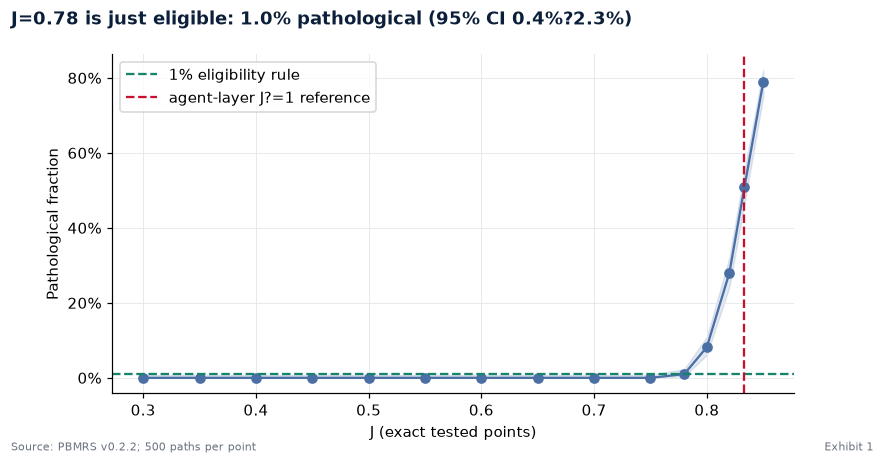

,J,sigma_eps,count,fraction,lo,hi
0,0.3000,0.01,0.0,0.000,0.0000,0.0076
1,0.3500,0.01,0.0,0.000,0.0000,0.0076
2,0.4000,0.01,0.0,0.000,0.0000,0.0076
3,0.4500,0.01,0.0,0.000,0.0000,0.0076
4,0.5000,0.01,0.0,0.000,0.0000,0.0076
5,0.5500,0.01,0.0,0.000,0.0000,0.0076
6,0.6000,0.01,0.0,0.000,0.0000,0.0076
7,0.6500,0.01,0.0,0.000,0.0000,0.0076
8,0.7000,0.01,0.0,0.000,0.0000,0.0076
9,0.7500,0.01,0.0,0.000,0.0000,0.0076


In [4]:
stab = pd.DataFrame(stability_cache["rows"], columns=["J","sigma_eps","count","fraction","lo","hi"])
base_stab = stab[np.isclose(stab.sigma_eps, 0.01)].copy()
eligible = base_stab.loc[base_stab.fraction <= 0.01, "J"].max()
row078 = base_stab[np.isclose(base_stab.J, 0.78)].iloc[0]
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(base_stab.J, base_stab.fraction, marker="o", color=BLUE)
ax.fill_between(base_stab.J, base_stab.lo, base_stab.hi, color=BLUE, alpha=.15)
ax.axhline(.01, color=GREEN, ls="--", label="1% eligibility rule")
ax.axvline(1/cfg.beta, color=RED, ls="--", label="agent-layer J?=1 reference")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))
ax.set(xlabel="J (exact tested points)", ylabel="Pathological fraction")
ax.legend()
title = (f"J=0.78 is just eligible: {row078.fraction:.1%} pathological "
         f"(95% CI {row078.lo:.1%}?{row078.hi:.1%})")
finish(fig, title, "Source: PBMRS v0.2.2; 500 paths per point", 1)
display(base_stab.round(4))

## Market and positioning context

CFTC positioning is contextual only and is never an input to J inference. Four definitions are reconciled to the deck?s quoted 14 July and 28 July anchors; the closest definition is shown with the WTI price path.

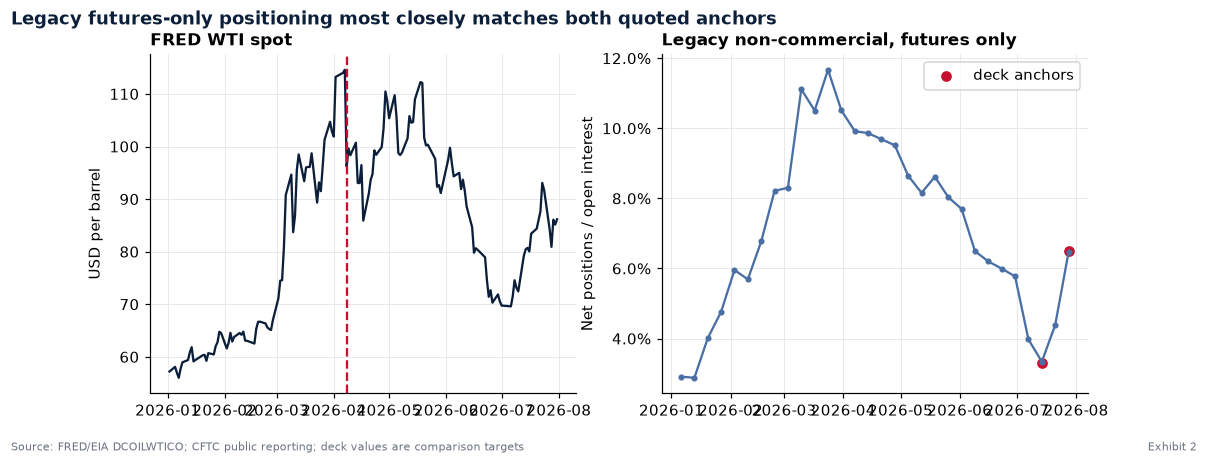

,definition,14 Jul,28 Jul,anchor error
3,"Legacy non-commercial, futures only",0.0334,0.0646,0.0008
1,"Disaggregated managed money, futures only",0.0330,0.0500,0.0151
0,"Disaggregated managed money, futures and options",0.0330,0.0427,0.0223
2,"Legacy non-commercial, futures and options",0.0516,0.0729,0.0264


In [5]:
cftc_series = [
    fetch_cftc_positioning(d, start="2026-01-01", end="2026-07-31", cache_dir=CACHE)
    for d in CFTC_DEFINITIONS
]
anchors = {"2026-07-14":0.033, "2026-07-28":0.065}
recon = []
for series in cftc_series:
    computed = [series.value_on(day) for day in anchors]
    recon.append({
        "definition":series.definition.label,
        "14 Jul":computed[0], "28 Jul":computed[1],
        "anchor error":sum(abs(computed[i]-v) for i,v in enumerate(anchors.values())),
    })
recon_df = pd.DataFrame(recon).sort_values("anchor error")
best = next(x for x in cftc_series if x.definition.label == recon_df.iloc[0]["definition"])
fig, axes = plt.subplots(1,2,figsize=(11,4))
axes[0].plot(wti.dates, wti.close, color=NAVY)
axes[0].axvline(np.datetime64("2026-04-08"), color=RED, ls="--")
axes[0].set(ylabel="USD per barrel", title="FRED WTI spot")
axes[1].plot(best.dates, best.net_over_oi, color=BLUE, marker="o", ms=3)
axes[1].scatter([np.datetime64(k) for k in anchors], list(anchors.values()), color=RED, label="deck anchors")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[1].set(ylabel="Net positions / open interest", title=best.definition.label)
axes[1].legend()
finish(fig, f"Legacy futures-only positioning most closely matches both quoted anchors",
       "Source: FRED/EIA DCOILWTICO; CFTC public reporting; deck values are comparison targets", 2)
display(recon_df.style.format({"14 Jul":"{:.4f}","28 Jul":"{:.4f}","anchor error":"{:.4f}"}))

The definition match is evidence about what the deck appears to mean by positioning, not a behavioral regressor. Prices come from the unspliced Cushing spot series, so the April result cannot be created by a front-month roll.

## Empirical dependence

Pointwise uncertainty uses a 2,000-resample stationary bootstrap with mean block length seven. The same statistic function returns all eight squared-return ACF lags, daily SD, and Fisher excess kurtosis.

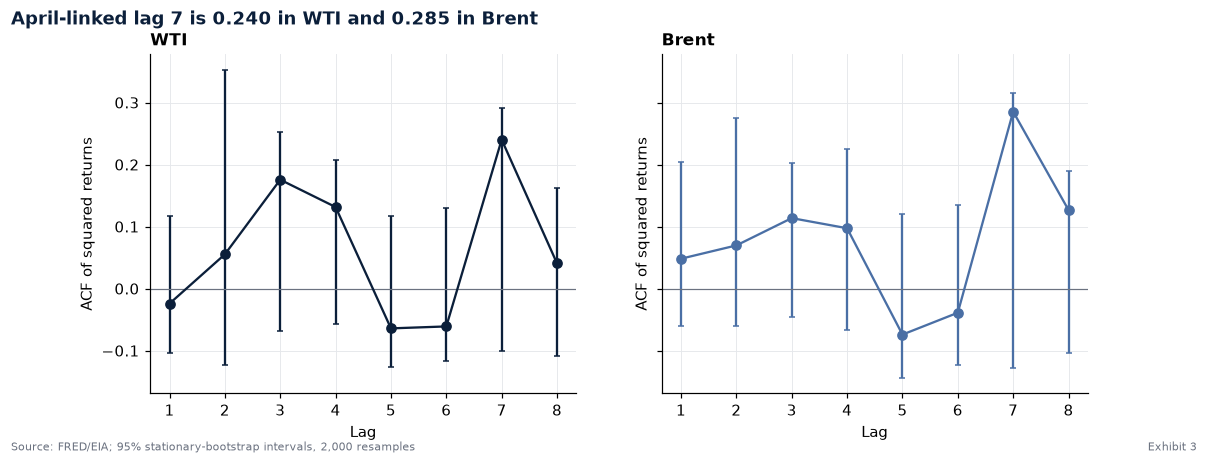

,series,daily SD,SD 95% low,SD 95% high,excess kurtosis,kurtosis 95% low,kurtosis 95% high
0,WTI,0.0418,0.0327,0.0507,2.6272,0.5930,4.8269
1,Brent,0.0453,0.0358,0.0537,1.3859,0.0693,3.2322


In [6]:
def empirical_stats(r):
    z = (r-r.mean())/r.std()
    return np.r_[acf_r2_profile(r, nlags=8), r.std(ddof=1), np.mean(z**4)-3]
wti_boot = bootstrap_statistic(wti_r, empirical_stats, n_boot=2000, mean_block=7, seed=7000)
brent_boot = bootstrap_statistic(brent_r, empirical_stats, n_boot=2000, mean_block=7, seed=7001)
lags = np.arange(1,9)
fig, axes = plt.subplots(1,2,figsize=(11,4),sharey=True)
for ax, boot, label, color in [(axes[0],wti_boot,"WTI",NAVY),(axes[1],brent_boot,"Brent",BLUE)]:
    ax.errorbar(lags, boot.point[:8], yerr=[boot.point[:8]-boot.lo[:8],boot.hi[:8]-boot.point[:8]],
                fmt="o-", color=color, capsize=2)
    ax.axhline(0,color=GREY,lw=.8)
    ax.set(xlabel="Lag", ylabel="ACF of squared returns", title=label)
finish(fig, f"April-linked lag 7 is {wti_boot.point[6]:.3f} in WTI and {brent_boot.point[6]:.3f} in Brent",
       "Source: FRED/EIA; 95% stationary-bootstrap intervals, 2,000 resamples", 3)
stats_table = pd.DataFrame({
    "series":["WTI","Brent"], "daily SD":[wti_boot.point[8],brent_boot.point[8]],
    "SD 95% low":[wti_boot.lo[8],brent_boot.lo[8]], "SD 95% high":[wti_boot.hi[8],brent_boot.hi[8]],
    "excess kurtosis":[wti_boot.point[9],brent_boot.point[9]],
    "kurtosis 95% low":[wti_boot.lo[9],brent_boot.lo[9]],
    "kurtosis 95% high":[wti_boot.hi[9],brent_boot.hi[9]],
})
display(stats_table.round(4))

## Match the finite sample

A T=2,000 model run describes the long-run marginal distribution of the statistic, not its sampling distribution at 144 positions. The comparison below recomputes lag-1 ACF path by path at both horizons.

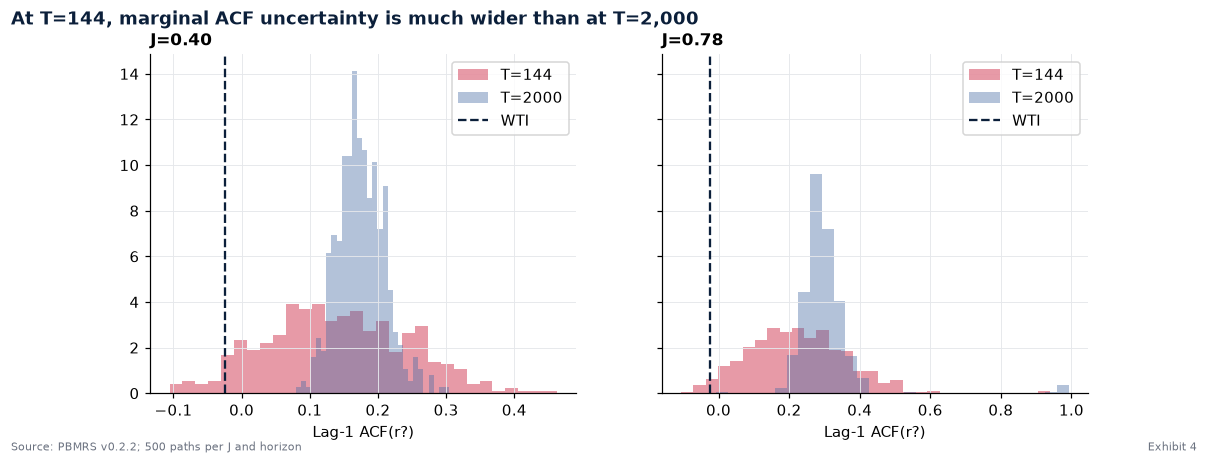

,J,T,mean,2.5%,97.5%
0,0.40,144,0.140,-0.050,0.341
1,0.40,2000,0.175,0.111,0.256
2,0.78,144,0.223,-0.015,0.498
3,0.78,2000,0.302,0.204,0.413


In [7]:
fig, axes = plt.subplots(1,2,figsize=(11,4),sharey=True)
spread_rows = []
for ax, j in zip(axes, (0.40,0.78)):
    for length,color in [(144,RED),(2000,BLUE)]:
        values = marginal_cache[f"J{j:.2f}_T{length}"]
        lag1 = np.array([acf_r2_profile(x,nlags=1)[0] for x in values])
        ax.hist(lag1,bins=30,density=True,alpha=.42,color=color,label=f"T={length}")
        spread_rows.append({"J":j,"T":length,"mean":lag1.mean(),"2.5%":np.percentile(lag1,2.5),"97.5%":np.percentile(lag1,97.5)})
    ax.axvline(acf_r2_profile(wti_r,nlags=1)[0],color=NAVY,ls="--",label="WTI")
    ax.set(xlabel="Lag-1 ACF(r?)", title=f"J={j:.2f}")
    ax.legend()
finish(fig, "At T=144, marginal ACF uncertainty is much wider than at T=2,000",
       "Source: PBMRS v0.2.2; 500 paths per J and horizon", 4)
display(pd.DataFrame(spread_rows).round(3))

## Joint adequacy test

D-sum is predeclared as primary. Calibration uses means and SDs from seeds 0?999; SD is floored at 1e-12. Seeds 1000?5998 form a disjoint null, p-values use the plus-one correction, and Wilson intervals show Monte Carlo uncertainty. Common random numbers across J reduce noise in differences between neighboring points but induce dependence across the plotted p-values.

In [8]:
def adequacy_frame(label, empirical, mask, profile_variant):
    valid = np.ones(len(empirical),bool) if mask is None else mask
    emp = acf_r2_profile(empirical,nlags=8,valid_mask=mask)
    rows = [evaluate_profile_bank(
        emp, profiles[i,profile_variant], J=float(j), beta=cfg.beta, n_cal=1000,
        alpha=.10, statistic="D_sum", valid_n=int(valid.sum()), variant=label,
    ) for i,j in enumerate(J)]
    return pd.DataFrame([dataclasses.asdict(x) for x in rows])

adequacy = pd.concat([
    adequacy_frame("WTI full",wti_r,None,0),
    adequacy_frame("WTI fixed-grid April mask",wti_r,wti_mask,1),
    adequacy_frame("Brent full",brent_r,None,0),
    adequacy_frame("Brent fixed-grid April mask",brent_r,brent_mask,2),
],ignore_index=True)
assert set(adequacy.n_cal)=={1000} and set(adequacy.n_null)=={4999}
assert set(adequacy[adequacy.variant.str.contains("mask")].valid_n)=={143}
adequacy.groupby("variant").agg(min_p=("p_value","min"),max_p=("p_value","max"),
                                non_rejected=("decision",lambda x:(x=="non_rejected").sum()))

,min_p,max_p,non_rejected
variant,,,
Brent fixed-grid April mask,0.1424,0.5152,15
Brent full,0.0196,0.3416,3
WTI fixed-grid April mask,0.2048,0.5758,15
WTI full,0.0254,0.3324,3


The decision is an inversion over exact tested points, not an estimate of a continuous J interval. A larger p-value is not a better fit; it only means this selected statistic supplies less evidence against that grid point.

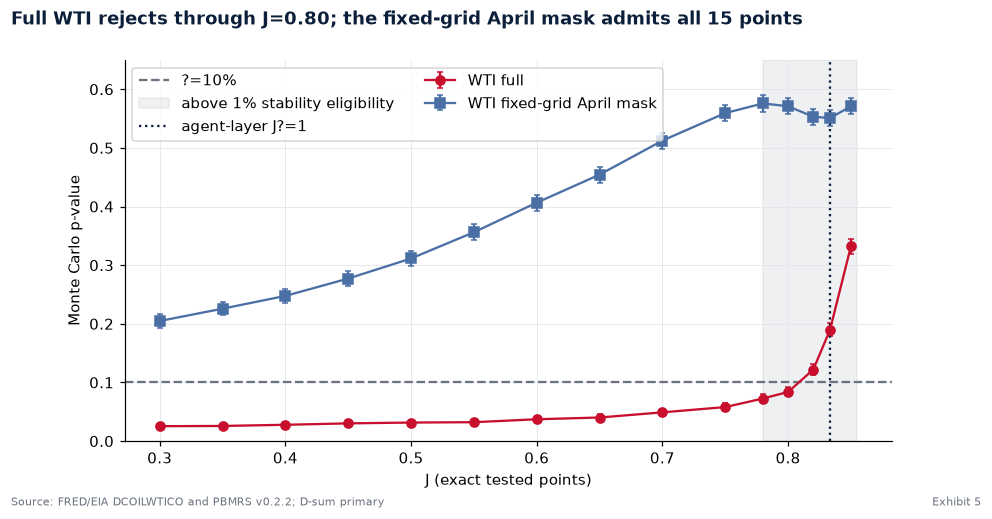

,variant,J,J_beta,p_value,mc_lo,mc_hi,decision,borderline
0,WTI full,0.3000,0.360,0.0254,0.0212,0.0299,rejected,False
1,WTI full,0.3500,0.420,0.0258,0.0216,0.0304,rejected,False
2,WTI full,0.4000,0.480,0.0278,0.0234,0.0325,rejected,False
3,WTI full,0.4500,0.540,0.0302,0.0256,0.0351,rejected,False
4,WTI full,0.5000,0.600,0.0316,0.0269,0.0366,rejected,False
5,WTI full,0.5500,0.660,0.0322,0.0275,0.0373,rejected,False
6,WTI full,0.6000,0.720,0.0372,0.0321,0.0426,rejected,False
7,WTI full,0.6500,0.780,0.0402,0.0349,0.0458,rejected,False
8,WTI full,0.7000,0.840,0.0490,0.0432,0.0551,rejected,False
9,WTI full,0.7500,0.900,0.0580,0.0517,0.0646,rejected,False


In [9]:
fig, ax = plt.subplots(figsize=(9,4.5))
for label,color,marker in [("WTI full",RED,"o"),("WTI fixed-grid April mask",BLUE,"s")]:
    part=adequacy[adequacy.variant==label]
    ax.errorbar(part.J,part.p_value,yerr=[part.p_value-part.mc_lo,part.mc_hi-part.p_value],
                color=color,marker=marker,capsize=2,label=label)
ax.axhline(.10,color=GREY,ls="--",label="?=10%")
ax.axvspan(.78, J.max()+.005, color=GREY, alpha=.10, label="above 1% stability eligibility")
ax.axvline(1/cfg.beta,color=NAVY,ls=":",label="agent-layer J?=1")
ax.set(xlabel="J (exact tested points)",ylabel="Monte Carlo p-value",ylim=(0,.65))
ax.legend(ncol=2)
full = adequacy[adequacy.variant=="WTI full"]
masked = adequacy[adequacy.variant=="WTI fixed-grid April mask"]
title=(f"Full WTI rejects through J={full[full.decision=='rejected'].J.max():.2f}; "
       f"the fixed-grid April mask admits all {len(masked)} points")
finish(fig,title,"Source: FRED/EIA DCOILWTICO and PBMRS v0.2.2; D-sum primary",5)
display(adequacy[adequacy.variant.str.startswith("WTI")][
    ["variant","J","J_beta","p_value","mc_lo","mc_hi","decision","borderline"]
].round(4))

At the highest stability-eligible comparison, J=0.78, full-sample p=0.0726 and fixed-grid-mask p=0.5758. Full-sample p-values generally increase with J, but this does not rank regimes by fit quality. The non-rejected full-sample points J=0.82, 1/beta, and 0.85 have base pathological rates of 28.0%, 50.8%, and 78.8%.

## April influence anatomy

The mask removes the 8 April return from all centering and lag pairs while preserving its existing position. The identical position is masked in every simulated path.

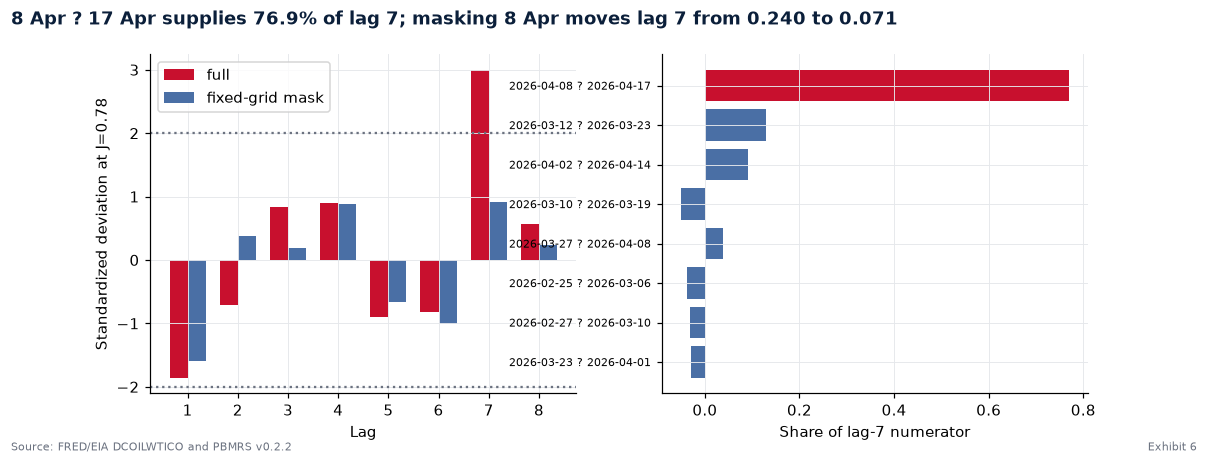

In [10]:
i078=int(np.flatnonzero(np.isclose(J,.78))[0])
cal=profiles[i078,0,:1000]
mu=cal.mean(axis=0); sd=np.maximum(cal.std(axis=0,ddof=1),1e-12)
z_full=(acf_r2_profile(wti_r)-mu)/sd
cal_mask=profiles[i078,1,:1000]
mu_mask=cal_mask.mean(axis=0); sd_mask=np.maximum(cal_mask.std(axis=0,ddof=1),1e-12)
z_mask=(acf_r2_profile(wti_r,valid_mask=wti_mask)-mu_mask)/sd_mask
contrib=lag_contributions(wti_r,7)
top=int(np.nanargmax(np.abs(contrib)))
fig,axes=plt.subplots(1,2,figsize=(11,4))
x=np.arange(1,9); width=.36
axes[0].bar(x-width/2,z_full,width,color=RED,label="full")
axes[0].bar(x+width/2,z_mask,width,color=BLUE,label="fixed-grid mask")
axes[0].axhline(2,color=GREY,ls=":");axes[0].axhline(-2,color=GREY,ls=":")
axes[0].set(xlabel="Lag",ylabel="Standardized deviation at J=0.78");axes[0].legend()
order=np.argsort(np.nan_to_num(np.abs(contrib),nan=-1))[-8:][::-1]
labels=[f"{wti_dates[k]} ? {wti_dates[k+7]}" for k in order]
axes[1].barh(np.arange(len(order)),contrib[order],color=[RED if k==top else BLUE for k in order])
axes[1].set_yticks(np.arange(len(order)),labels=labels,fontsize=7);axes[1].invert_yaxis()
axes[1].set(xlabel="Share of lag-7 numerator")
pair_share=contrib[top]
title=(f"8 Apr ? 17 Apr supplies {pair_share:.1%} of lag 7; masking 8 Apr "
       f"moves lag 7 from {acf_r2_profile(wti_r)[6]:.3f} to {acf_r2_profile(wti_r,valid_mask=wti_mask)[6]:.3f}")
finish(fig,title,"Source: FRED/EIA DCOILWTICO and PBMRS v0.2.2",6)

This is exploratory influence analysis because the date was identified after seeing the result. It does not license choosing whichever treatment gives a preferred answer. Compressed deletion and a merged-return construction are therefore reported only in the appendix.

## FRED replication

Brent uses its final 144 return positions through 31 July; 8 April is found by date and masked at its own existing position. Both sources are unspliced spot series.

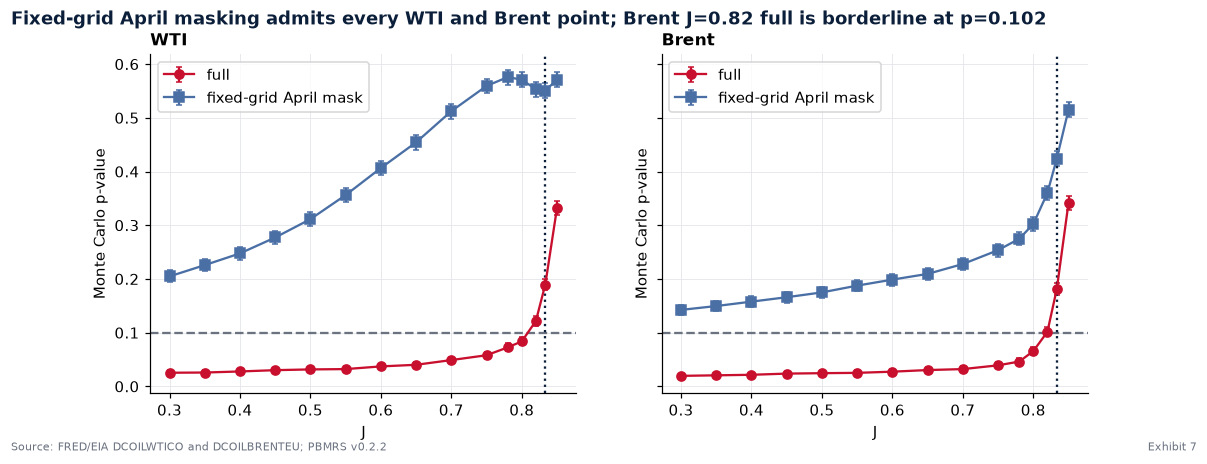

,minimum_p,maximum_p,rejected_points,borderline_points
variant,,,,
Brent fixed-grid April mask,0.1424,0.5152,0,0
Brent full,0.0196,0.3416,12,1
WTI fixed-grid April mask,0.2048,0.5758,0,0
WTI full,0.0254,0.3324,12,0


In [11]:
fig,axes=plt.subplots(1,2,figsize=(11,4),sharey=True)
for ax,source in zip(axes,("WTI","Brent")):
    for suffix,color,marker in [("full",RED,"o"),("fixed-grid April mask",BLUE,"s")]:
        label=f"{source} {suffix}"
        part=adequacy[adequacy.variant==label]
        ax.errorbar(part.J,part.p_value,yerr=[part.p_value-part.mc_lo,part.mc_hi-part.p_value],
                    color=color,marker=marker,capsize=2,label=suffix)
    ax.axhline(.10,color=GREY,ls="--");ax.axvline(1/cfg.beta,color=NAVY,ls=":")
    ax.set(title=source,xlabel="J",ylabel="Monte Carlo p-value");ax.legend()
br82=adequacy[(adequacy.variant=="Brent full")&np.isclose(adequacy.J,.82)].iloc[0]
title=(f"Fixed-grid April masking admits every WTI and Brent point; "
       f"Brent J=0.82 full is borderline at p={br82.p_value:.3f}")
finish(fig,title,"Source: FRED/EIA DCOILWTICO and DCOILBRENTEU; PBMRS v0.2.2",7)
rep=adequacy.groupby("variant").agg(
    minimum_p=("p_value","min"),maximum_p=("p_value","max"),
    rejected_points=("decision",lambda x:(x=="rejected").sum()),
    borderline_points=("borderline","sum"),
)
display(rep.round(4))

## Point-contrast power

Power compares null J=0.40 with truth J=0.78, the highest comparison allowed by the base-scale point-rate rule. Each T uses 500 independent pseudo-samples and the same 1,000/4,999 calibration/null structure.

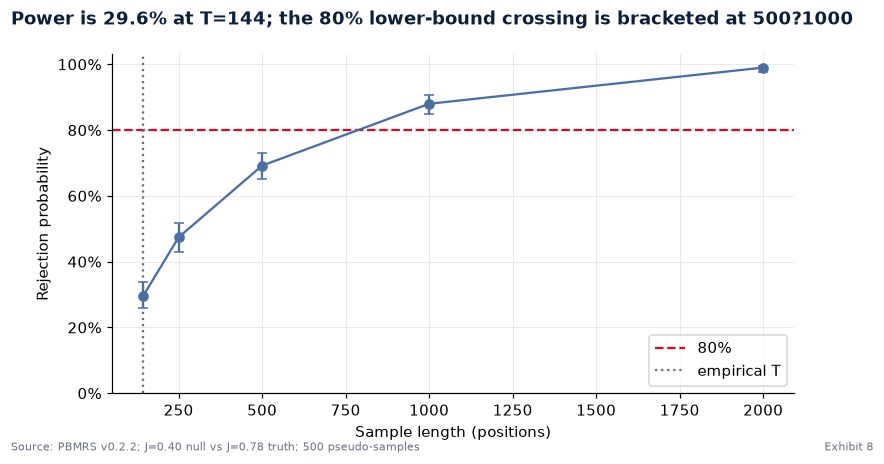

,T,rejected,power,lo,hi
0,144.0,148.0,0.296,0.2577,0.3374
1,250.0,237.0,0.474,0.4306,0.5178
2,500.0,346.0,0.692,0.6502,0.7309
3,1000.0,440.0,0.880,0.8486,0.9056
4,2000.0,495.0,0.990,0.9768,0.9957


In [12]:
power=pd.DataFrame(power_cache["rows"],columns=["T","rejected","power","lo","hi"])
fig,ax=plt.subplots(figsize=(8,4))
ax.errorbar(power["T"],power.power,yerr=[power.power-power.lo,power.hi-power.power],
            color=BLUE,marker="o",capsize=3)
ax.axhline(.8,color=RED,ls="--",label="80%")
ax.axvline(144,color=GREY,ls=":",label="empirical T")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))
ax.set(xlabel="Sample length (positions)",ylabel="Rejection probability",ylim=(0,1.03))
ax.legend()
cross=power[power.lo>.8]
bracket="not reached" if cross.empty else f"{int(power[power['T']<cross.iloc[0]['T']]['T'].max())}?{int(cross.iloc[0]['T'])}"
finish(fig,f"Power is {power.iloc[0].power:.1%} at T=144; the 80% lower-bound crossing is bracketed at {bracket}",
       "Source: PBMRS v0.2.2; J=0.40 null vs J=0.78 truth; 500 pseudo-samples",8)
display(power.round(4))

The tested bracket is 500?1,000 positions; no exact sample-size target is interpolated. At 144 positions the point contrast rejects only 29.6% of the time, so non-rejection after April masking is absence of discrimination, not confirmation of the deck?s regime language.

## Unconditional 21-session regime consequences

These are unconditional simulated regime contrasts with no predictive claim. Every path contains 500 burn-in returns plus exactly 21 evaluation returns; evaluation prices restart at one after burn-in. Round trips are discussed only through recovery and ending drawdown.

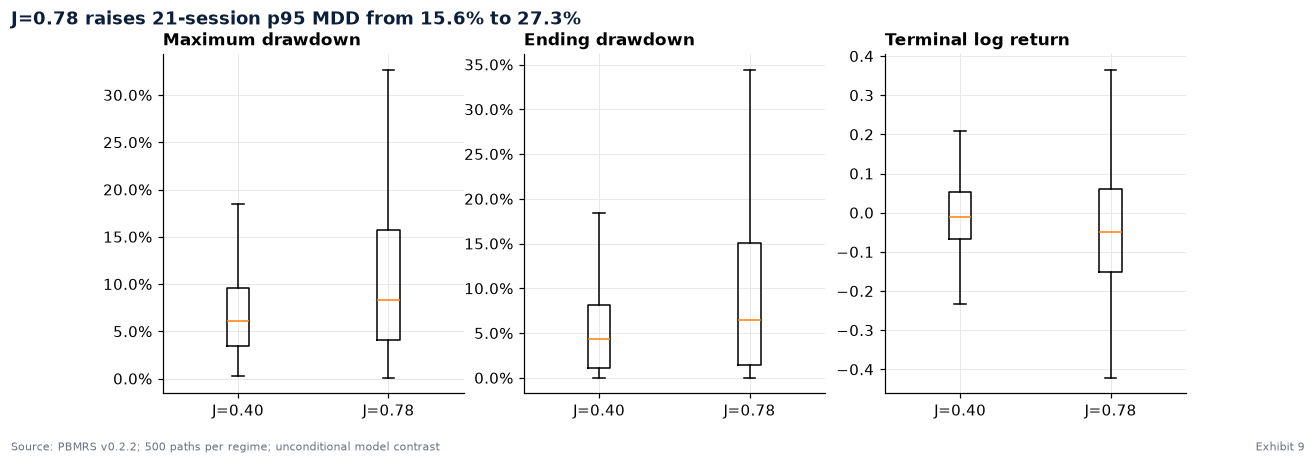

,J,MDD mean,MDD p95,terminal log return mean,ending drawdown mean,paths with at least 5% DD,recovery rate after 5% DD
0,0.40,0.0691,0.1558,-0.0069,0.0528,308,0.0747
1,0.78,0.1069,0.2731,-0.0515,0.0931,340,0.0588


In [13]:
h=horizon_cache
fig,axes=plt.subplots(1,3,figsize=(12,4))
labels=["J=0.40","J=0.78"]; colors=[BLUE,RED]
for idx,(name,arr) in enumerate([
    ("Maximum drawdown",h["max_drawdown"]),("Ending drawdown",h["ending_drawdown"]),
    ("Terminal log return",h["terminal_log_return"]),
]):
    axes[idx].boxplot([arr[0],arr[1]],tick_labels=labels,showfliers=False)
    axes[idx].set_title(name)
    if idx<2: axes[idx].yaxis.set_major_formatter(mtick.PercentFormatter(1))
summary=[]
for i,j in enumerate(h["J"]):
    q=h["qualifying_drawdown"][i].astype(bool); recovered=h["recovered"][i].astype(bool)
    summary.append({
        "J":j,"MDD mean":h["max_drawdown"][i].mean(),"MDD p95":np.percentile(h["max_drawdown"][i],95),
        "terminal log return mean":h["terminal_log_return"][i].mean(),
        "ending drawdown mean":h["ending_drawdown"][i].mean(),
        "paths with at least 5% DD":q.sum(),"recovery rate after 5% DD":recovered[q].mean(),
    })
summary=pd.DataFrame(summary)
finish(fig,f"J=0.78 raises 21-session p95 MDD from {summary.iloc[0]['MDD p95']:.1%} to {summary.iloc[1]['MDD p95']:.1%}",
       "Source: PBMRS v0.2.2; 500 paths per regime; unconditional model contrast",9)
display(summary.round(4))

## What the evidence licenses

The deck?s near-critical language remains out of reach on this window. With the influential session included, the selected statistic rejects every stability-eligible tested point. With its position masked, every tested point is non-rejected, but power at T=144 is only 29.6% for the declared J=0.40 versus J=0.78 contrast. The defensible conclusion is sensitivity plus limited discrimination, conditional on this statistic and fixed configuration, with no predictive claim.

# Appendix
## Specification checks and alternative April treatments

D-max and median/IQR are checks, not co-primary searches. Fixed-grid masking remains the main sensitivity; compressed deletion changes the lag adjacency, while merging the 8 April return into the next observed return asks a different economic question.

In [14]:
checks=[]
for statistic in ("D_max","robust"):
    for label,mask,variant in [("full",None,0),("fixed-grid mask",wti_mask,1)]:
        emp=acf_r2_profile(wti_r,valid_mask=mask)
        for i,j in enumerate(J):
            row=evaluate_profile_bank(emp,profiles[i,variant],J=float(j),beta=cfg.beta,n_cal=1000,
                                      alpha=.10,statistic=statistic,valid_n=144-int(mask is not None),variant=label)
            checks.append(dataclasses.asdict(row))
display(pd.DataFrame(checks).groupby(["statistic","variant"]).agg(
    minimum_p=("p_value","min"),maximum_p=("p_value","max"),
    rejected_points=("decision",lambda x:(x=="rejected").sum())).round(4))
compressed=np.delete(wti_r,april_wti)
merged=np.delete(wti_r,april_wti); merged[april_wti]+=wti_r[april_wti]
alternatives=pd.DataFrame({
    "lag":np.arange(1,9),"full":acf_r2_profile(wti_r),
    "fixed-grid mask":acf_r2_profile(wti_r,valid_mask=wti_mask),
    "compressed deletion":acf_r2_profile(compressed),
    "merged return":acf_r2_profile(merged),
})
display(alternatives.round(4))

minimum_p  maximum_p  rejected_points
statistic variant                                               
D_max     fixed-grid mask     0.2998     0.7152                0
          full                0.0170     0.2542               13
robust    fixed-grid mask     0.1758     0.7266                0
          full                0.0240     0.2242               12

,lag,full,fixed-grid mask,compressed deletion,merged return
0,1,-0.0241,0.0091,0.0098,-0.0259
1,2,0.0553,0.1792,0.1809,0.1037
2,3,0.1756,0.1031,0.0995,0.2668
3,4,0.1315,0.1298,0.1161,0.0556
4,5,-0.0641,-0.0414,-0.0387,-0.0489
5,6,-0.0610,-0.0776,-0.0177,0.1442
6,7,0.2402,0.0709,-0.0107,0.0252
7,8,0.0407,0.0131,0.0199,0.0156


## Controls

The positive controls use 500 true-model pseudo-samples at each point. The matched Gaussian negative control is shown to explain why a flat ACF profile can be non-rejected even though it is not evidence for the simulator?s economic mechanism.

In [15]:
controls=pd.DataFrame(controls_cache["rows"],columns=["J","rejected","rate","lo","hi"])
controls["nominal_inside_interval"]=(controls.lo<=.10)&(.10<=controls.hi)
rng=np.random.default_rng(9000)
gaussian=rng.normal(0,wti_r.std(),144)
negative=[]
for i,j in enumerate(J):
    row=evaluate_profile_bank(acf_r2_profile(gaussian),profiles[i,0],J=float(j),beta=cfg.beta,
                              n_cal=1000,alpha=.10,statistic="D_sum",valid_n=144,variant="Gaussian")
    negative.append({"J":j,"p_value":row.p_value,"decision":row.decision})
display(controls.round(4))
display(pd.DataFrame(negative).round(4))
print("A flat Gaussian ACF can sit near the center of the model statistic distribution; non-rejection is not mechanism validation.")

,J,rejected,rate,lo,hi,nominal_inside_interval
0,0.40,47.0,0.094,0.0714,0.1228,True
1,0.78,57.0,0.114,0.0890,0.1448,True


,J,p_value,decision
0,0.3000,0.2266,non_rejected
1,0.3500,0.2208,non_rejected
2,0.4000,0.2182,non_rejected
3,0.4500,0.2116,non_rejected
4,0.5000,0.2038,non_rejected
5,0.5500,0.1962,non_rejected
6,0.6000,0.1888,non_rejected
7,0.6500,0.1802,non_rejected
8,0.7000,0.1732,non_rejected
9,0.7500,0.1604,non_rejected


A flat Gaussian ACF can sit near the center of the model statistic distribution; non-rejection is not mechanism validation.


## Complete stability phase map and configuration

This table is the complete J by sigma-epsilon stability grid. It is an empirical phase map of pathological fractions, not a proof that J times beta equals one is the full system?s boundary.

In [16]:
phase=stab.pivot(index="sigma_eps",columns="J",values="fraction")
display(phase.style.format("{:.1%}"))
display(pd.DataFrame([dataclasses.asdict(cfg)]).T.rename(columns={0:"base.yaml value"}))
print("Exact J grid:", [float(x) for x in J])
print("Mask indices:", {"WTI":april_wti,"Brent":april_brent})

J,0.300000,0.350000,0.400000,0.450000,0.500000,0.550000,0.600000,0.650000,0.700000,0.750000,0.780000,0.800000,0.820000,0.833333,0.850000
sigma_eps,,,,,,,,,,,,,,,
0.010000,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,1.0%,8.2%,28.0%,50.8%,78.8%
0.015000,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.8%,22.8%,62.8%,85.4%,97.4%,99.6%,100.0%
0.020000,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.2%,6.8%,44.4%,93.0%,99.4%,100.0%,100.0%,100.0%,100.0%
0.030000,0.0%,0.2%,0.4%,2.8%,17.2%,57.4%,91.4%,99.8%,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%
0.037000,7.6%,21.8%,56.0%,87.8%,98.6%,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%


,base.yaml value
seed,42.000000
timesteps,2000.000000
dt,1.000000
n_agents,2000.000000
q0,0.000500
beta,1.200000
J,0.500000
alpha_r,12.000000
alpha_v,0.001000
alpha_l,0.100000


Exact J grid: [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.78, 0.8, 0.82, 0.8333333333333334, 0.85]
Mask indices: {'WTI': 64, 'Brent': 63}


## Provenance, seeds, and environment

Every simulation cache key covers code, complete configuration, data manifest, mask, grid, and seed settings. The raw-response manifest separately binds each upstream payload to its source URL and SHA-256.

In [17]:
raw_provenance=pd.DataFrame(data_manifest["entries"].values())
display(raw_provenance[["source_name","retrieved_at_utc","byte_count","sha256","url"]])
display(pd.DataFrame(settings["seed_ledger"].items(),columns=["purpose","seed block"]))
try:
    git_hash=subprocess.check_output(["git","rev-parse","HEAD"],cwd=ROOT,text=True).strip()
except Exception:
    git_hash="unavailable"
print({"python":platform.python_version(),"numpy":np.__version__,"pandas":pd.__version__,
       "PBMRS":__version__,"git":git_hash,"code_hash":settings["code_hash"]})

,source_name,retrieved_at_utc,byte_count,sha256,url
0,cftc_6dca-aqww_2026-01-01_2026-07-31.json,2026-09-14T20:45:21.066799+00:00,4921,0ccbd7f9862345de238a4335dd36610df9edf6559dd358...,https://publicreporting.cftc.gov/resource/6dca...
1,cftc_72hh-3qpy_2026-01-01_2026-07-31.json,2026-09-14T20:45:19.940220+00:00,4918,4ce190e967ecbd47bed22cf59a8ba2b926afe756592ff5...,https://publicreporting.cftc.gov/resource/72hh...
2,cftc_jun7-fc8e_2026-01-01_2026-07-31.json,2026-09-14T20:45:20.420518+00:00,4921,ddb4a3d33fa103e6d177d44c9d952f22fd31a5cba78ffa...,https://publicreporting.cftc.gov/resource/jun7...
3,cftc_kh3c-gbw2_2026-01-01_2026-07-31.json,2026-09-14T20:45:19.489833+00:00,4901,da21974bff110002cc1aeb780e3e8152c3c57dcb6c38d0...,https://publicreporting.cftc.gov/resource/kh3c...
4,fred_DCOILBRENTEU_2026-01-01_2026-07-31.csv,2026-09-14T20:45:18.913264+00:00,2629,85dad56491c41fe902ce16cc332d5b8b60ca29f1d97ccd...,https://fred.stlouisfed.org/graph/fredgraph.cs...
5,fred_DCOILWTICO_2026-01-01_2026-07-31.csv,2026-09-14T20:45:18.552479+00:00,2589,6bc68e8cbce3351dc5515e4f36a7d9f665e95c34967188...,https://fred.stlouisfed.org/graph/fredgraph.cs...


,purpose,seed block
0,adequacy_calibration,"[0, 999]"
1,adequacy_null,"[1000, 5998]"
2,controls,254000 and 257800 series
3,horizon,404000 and 407800 series
4,marginals,"500000-series, disjoint by J and T"
5,power,"100000-series, disjoint by T"
6,stability,"[50000, 50499]"


{'python': '3.14.4', 'numpy': '2.5.1', 'pandas': '3.0.5', 'PBMRS': '0.2.2', 'git': '41ffcfff15202d506112de990deda1e6dd37d1cb', 'code_hash': '06ed76c69f72c612b2f42fed04e2803136456a8dc2443eb38fd8b3929328ce99'}


## Limitations and next steps

The window is short, April influence was identified post hoc, and one simulator step is assumed to represent one trading session. All parameters other than J are fixed at base.yaml, while innovation scale is not separable from stability. J=0.78 only just meets the point-rate eligibility rule, and the coupled system has no proven critical boundary. CFTC is weekly context, not identification data. The Gaussian innovation omits geopolitical jumps, while multiple comparisons and alternative windows are not promoted into primary claims.

Next work should introduce an explicit jump or heavy-tail innovation, test multi-year and rolling windows, improve dynamics so the agent-layer reference is numerically reachable, and pre-register influence handling before a new sample is observed. Optional Yahoo futures can then be used only as a non-load-bearing reconciliation.